# Task 2: Yelp Polarity sentiment classification

Runs `train_sentiment.py` (config: `sentiment_config.json`) and shows every result inline.
All numbers are read from the script's own output files, so they match the raw log in `../logs/`.

In [ ]:
import sys
print("Python", sys.version.split()[0])
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

## 1. Train and evaluate all three models
Set `RUN_TRAINING = False` to only display the results of the last run.

In [2]:
RUN_TRAINING = True
if RUN_TRAINING:
    !"{sys.executable}" train_sentiment.py

Run 20261001_192101
Hardware: {"device": "cuda", "cpu": "12th Gen Intel(R) Core(TM) i9-12900HK", "platform": "Windows-11-10.0.26200-SP0", "gpu": "NVIDIA GeForce RTX 3080 Ti Laptop GPU", "gpu_memory_gb": 16.0, "cuda_version": "12.8"}
Config: {"seed": 266, "data": {"dataset": "yelp_polarity", "data_dir": "data", "train_limit": 100000, "val_fraction": 0.1, "test_limit": 10000}, "preprocessing": {"max_length": 120, "min_frequency": 2, "expand_negations": true, "stemming": true, "stopwords": ["a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in", "is", "it", "its", "of", "on", "that", "the", "this", "to", "was", "we", "were", "with", "you", "your"]}, "training": {"batch_size": 128, "epochs": 5, "early_stopping_patience": 2, "lr": 0.002}, "models": {"baseline_mean": {"type": "mean", "embedding_dim": 64, "hidden_dim": 64}, "experimental_cnn": {"type": "cnn", "embedding_dim": 96, "channels": 96, "kernel_sizes": [3, 4, 5]}, "experimental_gru": {"type": "gru", "embedd

In [3]:
import csv, json
from pathlib import Path
from IPython.display import Image, Markdown, display

MEMBER_DIR = Path.cwd().parent          # notebook lives in <task>/<member>/src/
OUT = MEMBER_DIR / "outputs"


def fmt(value):
    try:
        number = float(value)
    except ValueError:
        return value
    return value if number.is_integer() and "." not in value else f"{number:.4g}"


def show_csv(path, transpose=False):
    rows = list(csv.reader(open(path, encoding="utf-8")))
    if transpose:
        rows = [list(column) for column in zip(*rows)]
    lines = ["| " + " | ".join(rows[0]) + " |", "|" + "---|" * len(rows[0])]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |" for row in rows[1:]]
    display(Markdown("\n".join(lines)))

## 2. Data analysis: review length, class balance, missing/malformed rows

train n=90,000 classes={'negative': 44992, 'positive': 45008} median_words=98 p90=284 truncated=26.2% duplicates=0
val   n=10,000 classes={'negative': 5008, 'positive': 4992} median_words=98 p90=285 truncated=25.4% duplicates=0
test  n=10,000 classes={'negative': 5000, 'positive': 5000} median_words=99 p90=282 truncated=26.0% duplicates=0
dropped (missing/malformed): {'train': {'malformed_rows': 0, 'missing_or_empty_text': 0, 'invalid_label': 0}, 'test': {'malformed_rows': 0, 'missing_or_empty_text': 0, 'invalid_label': 0}}


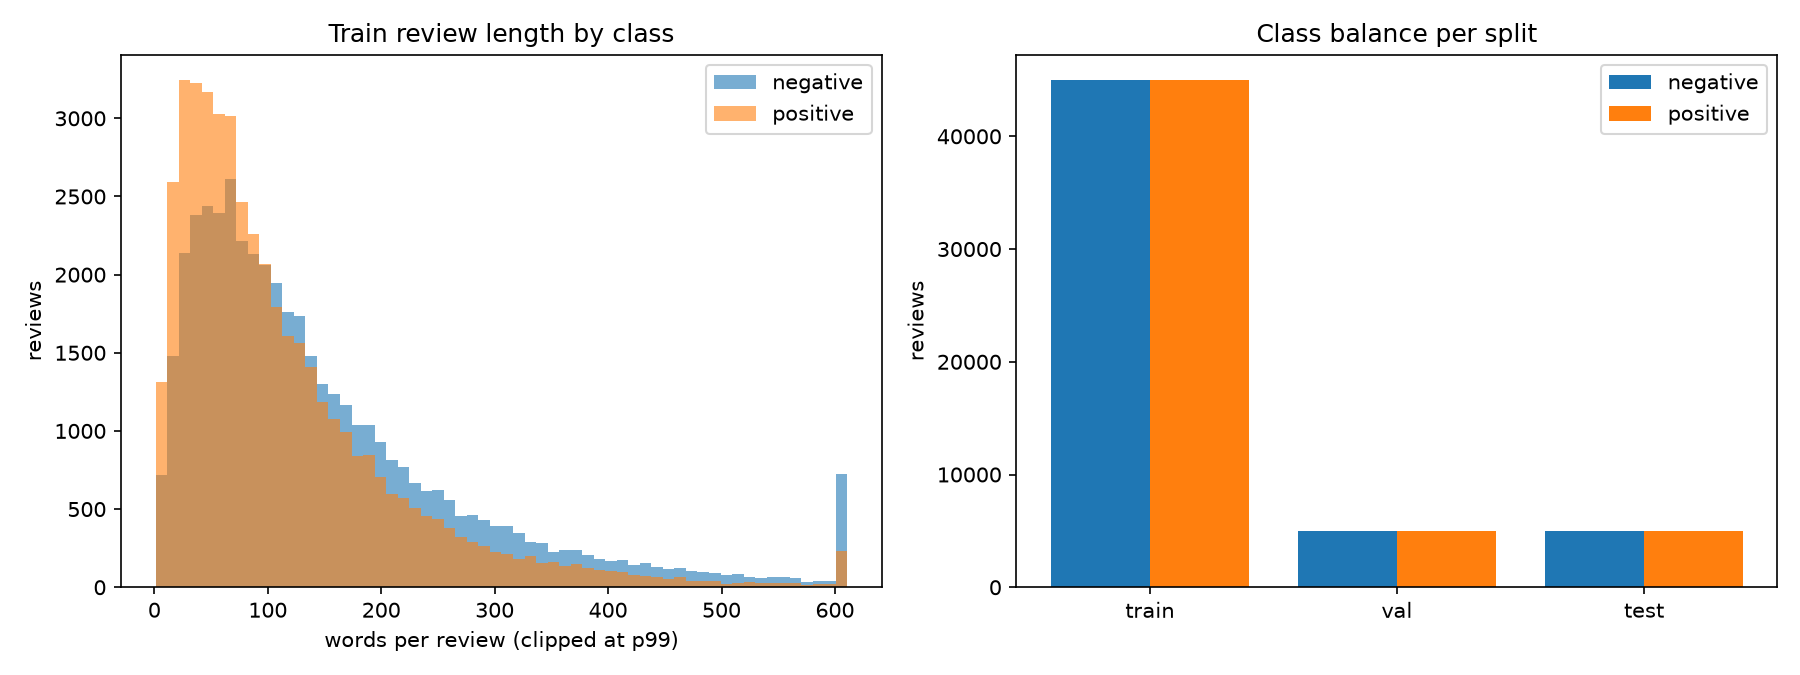

In [4]:
eda = json.load(open(OUT / "eda.json"))
for split in ("train", "val", "test"):
    e = eda[split]
    print(f"{split:5s} n={e['count']:,} classes={e['class_counts']} median_words={e['raw_word_length']['median']:.0f} "
          f"p90={e['raw_word_length']['p90']:.0f} truncated={e['fraction_truncated_at_max_length']:.1%} duplicates={e['duplicate_texts']}")
print("dropped (missing/malformed):", eda["dropped_rows"])
display(Image(OUT / "eda.png"))

## 3. Training curves

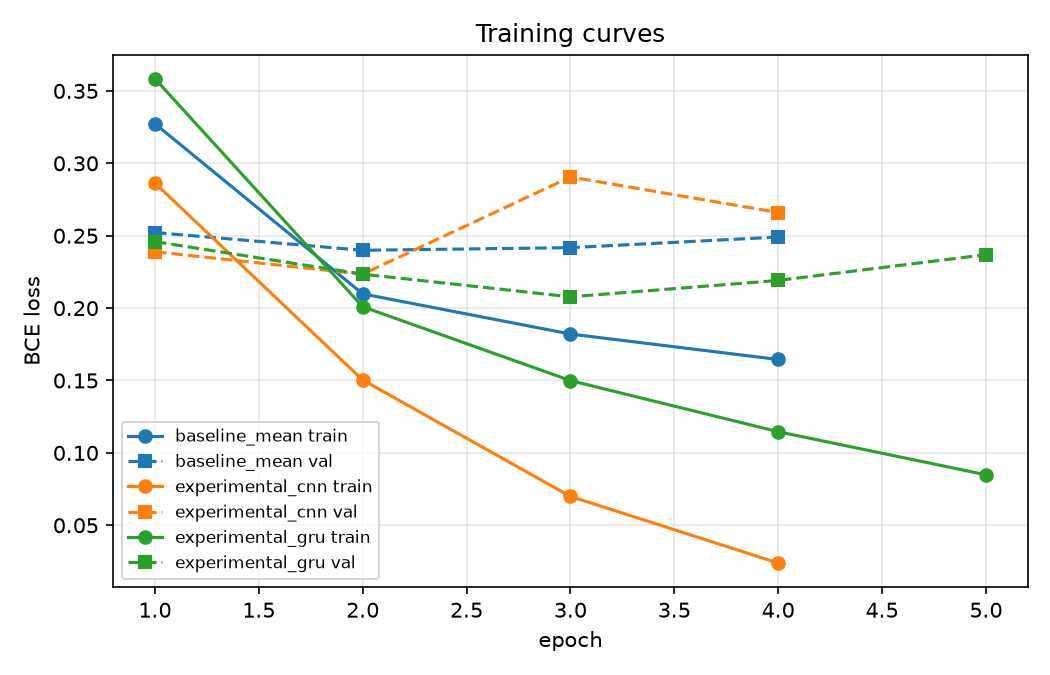

In [5]:
display(Image(OUT / "training_curves.png"))

## 4. Full metrics report (one row per model)

In [6]:
show_csv(MEMBER_DIR / "metrics_report.csv", transpose=True)

| model | baseline_mean | experimental_cnn | experimental_gru |
|---|---|---|---|
| accuracy | 0.9119 | 0.9143 | 0.9258 |
| precision_macro | 0.9119 | 0.9145 | 0.9262 |
| recall_macro | 0.9119 | 0.9143 | 0.9258 |
| f1_macro | 0.9119 | 0.9143 | 0.9258 |
| precision_micro | 0.9119 | 0.9143 | 0.9258 |
| recall_micro | 0.9119 | 0.9143 | 0.9258 |
| f1_micro | 0.9119 | 0.9143 | 0.9258 |
| precision_weighted | 0.9119 | 0.9145 | 0.9262 |
| recall_weighted | 0.9119 | 0.9143 | 0.9258 |
| f1_weighted | 0.9119 | 0.9143 | 0.9258 |
| roc_auc | 0.9705 | 0.9755 | 0.9785 |
| pr_auc | 0.9703 | 0.9755 | 0.9791 |
| mcc | 0.8238 | 0.8288 | 0.852 |
| brier_score | 0.0646 | 0.0621 | 0.05534 |
| ece | 0.006885 | 0.02712 | 0.0165 |
| parameter_count | 2058241 | 3192193 | 2104065 |
| best_epoch | 2 | 2 | 3 |
| epochs_run | 4 | 4 | 5 |
| training_seconds | 10.53 | 16.4 | 17.36 |
| train_examples_per_second | 3.42e+04 | 2.195e+04 | 2.592e+04 |
| inference_examples_per_second | 1.063e+05 | 7.378e+04 | 7.883e+04 |
| gpu_peak_allocated_mb | 57.86 | 102.4 | 236.6 |
| cpu_peak_rss_mb_process | 1755 | 1872 | 1911 |
| checkpoint | task2_sentiment/shulamite/checkpoints/baseline_mean.pt | task2_sentiment/shulamite/checkpoints/experimental_cnn.pt | task2_sentiment/shulamite/checkpoints/experimental_gru.pt |
| cm_tn | 4583 | 4516 | 4710 |
| cm_fp | 417 | 484 | 290 |
| cm_fn | 464 | 373 | 452 |
| cm_tp | 4536 | 4627 | 4548 |
| accuracy_ci95_low | 0.9065 | 0.9089 | 0.9206 |
| accuracy_ci95_high | 0.9173 | 0.9197 | 0.9312 |
| macro_f1_ci95_low | 0.9065 | 0.9089 | 0.9206 |
| macro_f1_ci95_high | 0.9173 | 0.9197 | 0.9312 |
| mcc_ci95_low | 0.8131 | 0.818 | 0.8417 |
| mcc_ci95_high | 0.8346 | 0.8397 | 0.8629 |
| slice_length_short_n | 1072 | 1072 | 1072 |
| slice_length_short_macro_f1 | 0.9081 | 0.9095 | 0.9211 |
| slice_length_short_error_rate | 0.08489 | 0.08302 | 0.07369 |
| slice_length_medium_n | 3307 | 3307 | 3307 |
| slice_length_medium_macro_f1 | 0.9258 | 0.9267 | 0.9421 |
| slice_length_medium_error_rate | 0.07348 | 0.07257 | 0.05745 |
| slice_length_long_n | 5621 | 5621 | 5621 |
| slice_length_long_macro_f1 | 0.9013 | 0.9052 | 0.9145 |
| slice_length_long_error_rate | 0.09731 | 0.09393 | 0.08415 |
| slice_with_negation_n | 7415 | 7415 | 7415 |
| slice_with_negation_macro_f1 | 0.8984 | 0.9033 | 0.9163 |
| slice_with_negation_error_rate | 0.09777 | 0.09373 | 0.08024 |
| slice_without_negation_n | 2585 | 2585 | 2585 |
| slice_without_negation_macro_f1 | 0.9154 | 0.9112 | 0.9219 |
| slice_without_negation_error_rate | 0.06035 | 0.06267 | 0.05687 |
| hardware | NVIDIA GeForce RTX 3080 Ti Laptop GPU | NVIDIA GeForce RTX 3080 Ti Laptop GPU | NVIDIA GeForce RTX 3080 Ti Laptop GPU |
| mcnemar_vs_baseline_baseline_only_correct |  | 351 | 252 |
| mcnemar_vs_baseline_experimental_only_correct |  | 375 | 391 |
| mcnemar_vs_baseline_test |  | exact binomial (two-sided) | exact binomial (two-sided) |
| mcnemar_vs_baseline_p_value |  | 0.3933 | 4.689e-08 |

## 5. Confusion matrices, ROC / PR curves and calibration

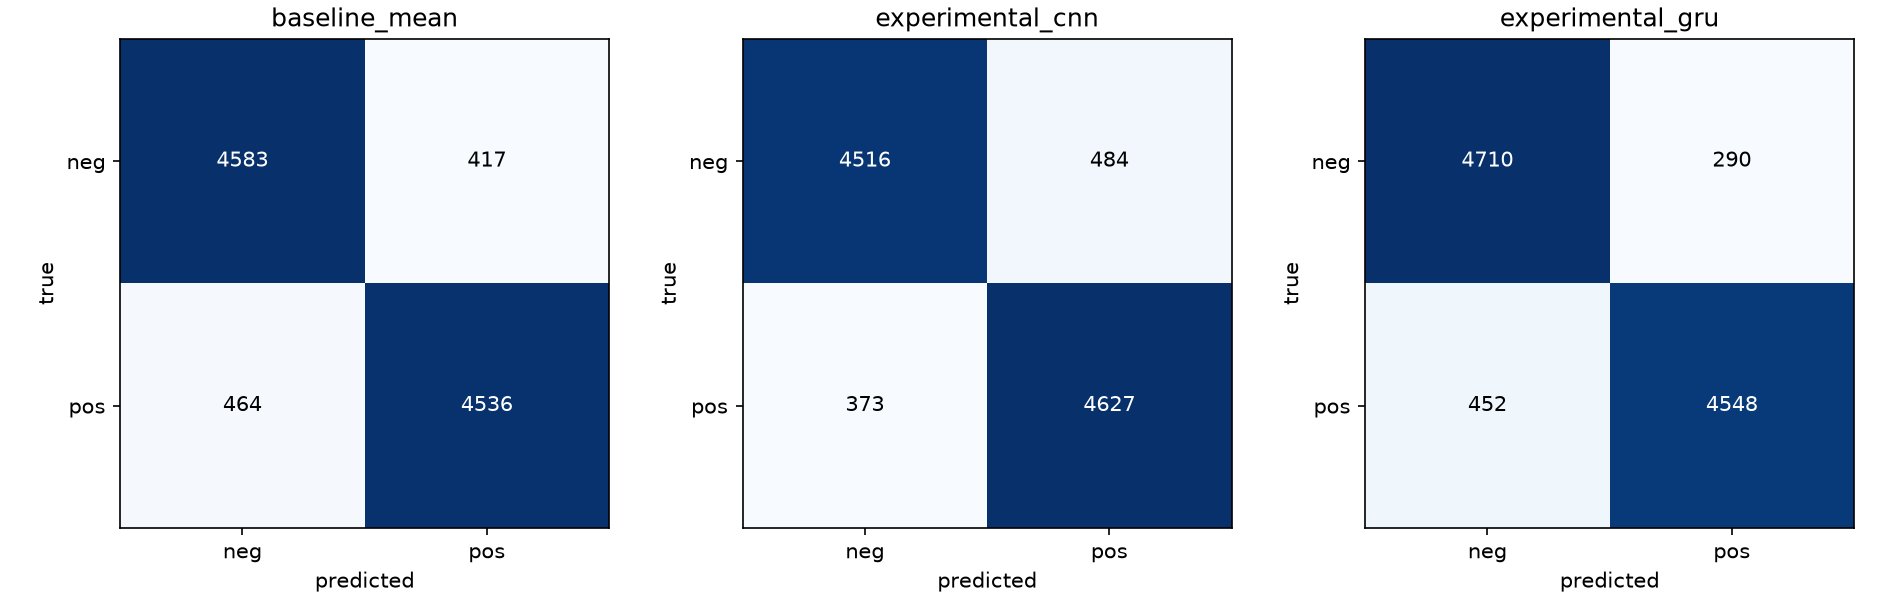

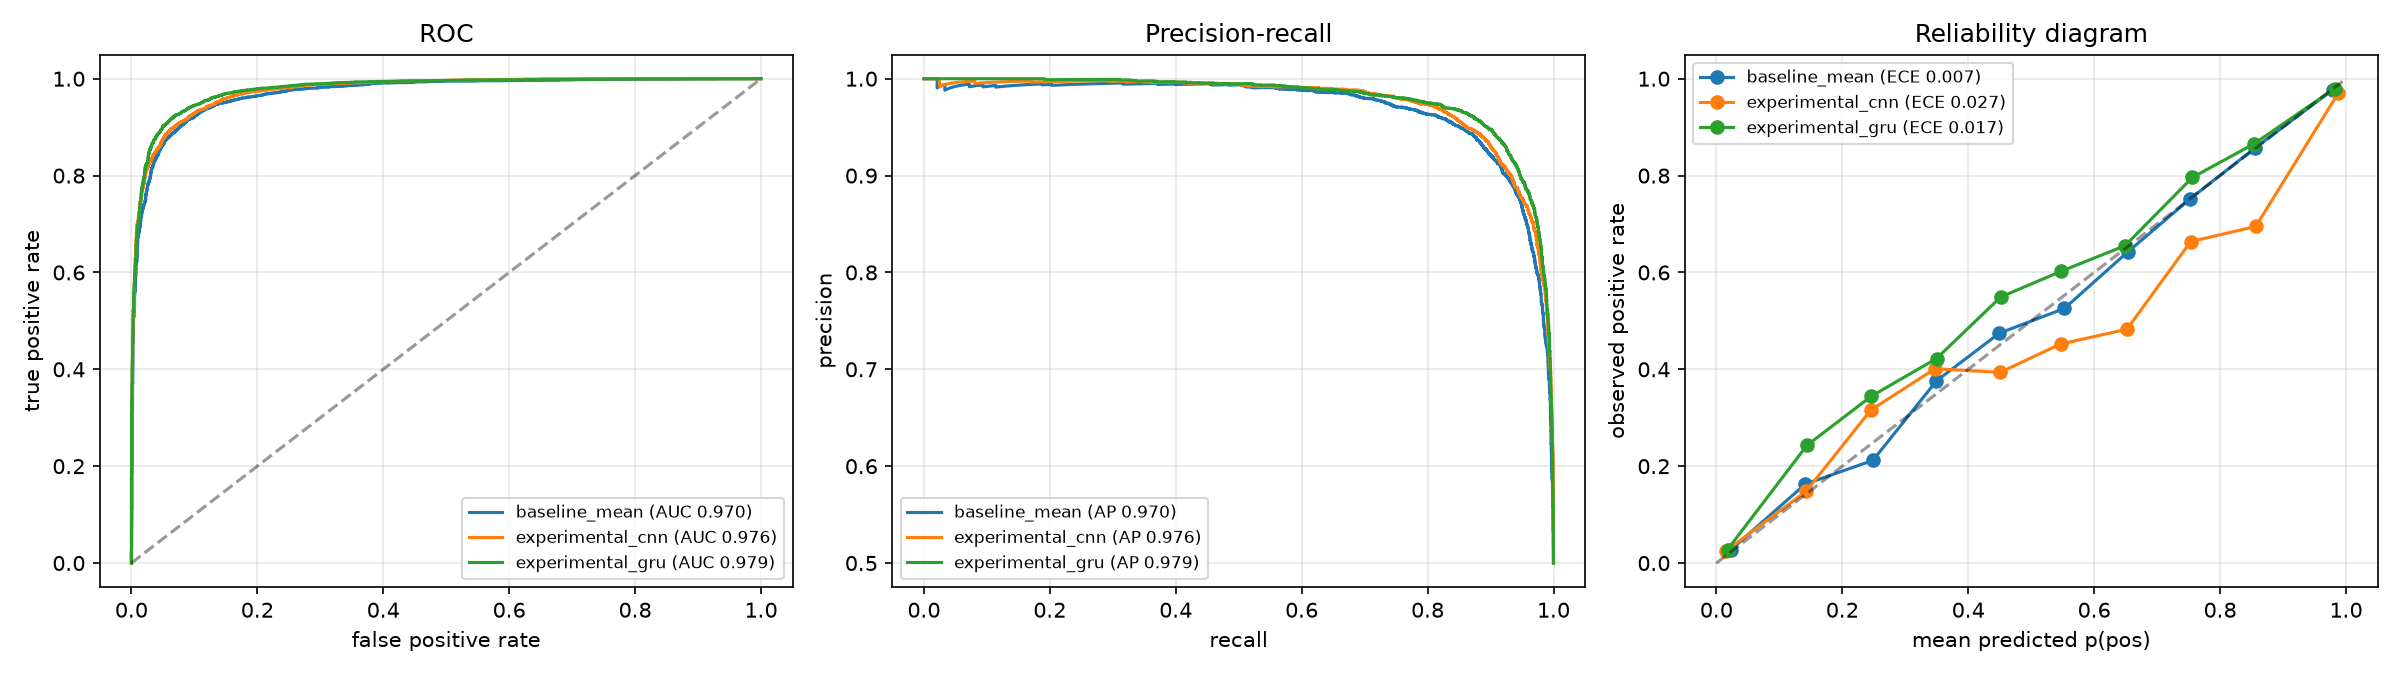

In [7]:
display(Image(OUT / "confusion_matrices.png"))
display(Image(OUT / "roc_pr_calibration.png"))

## 6. Bootstrap CIs, McNemar tests and per-slice robustness

In [8]:
results = json.load(open(OUT / "metrics.json"))["results"]
for name, r in results.items():
    print(f"\n{name}  (hardware: {r['hardware'].get('gpu')} / {r['hardware']['cpu']})")
    if "mcnemar_vs_baseline" in r:
        print("  McNemar vs baseline:", r["mcnemar_vs_baseline"])
    print("  95% CI:", r["bootstrap_ci_95"])
    for s, v in r["slice_metrics"].items():
        print(f"  {s:18s} n={v['count']:5d} macro-F1={v['macro_f1']:.4f} error={v['error_rate']:.4f}")


baseline_mean  (hardware: NVIDIA GeForce RTX 3080 Ti Laptop GPU / 12th Gen Intel(R) Core(TM) i9-12900HK)
  95% CI: {'accuracy': [0.9065, 0.9173], 'macro_f1': [0.9064990223385114, 0.9172813998635597], 'mcc': [0.8130981452079863, 0.8346315728027707]}
  length_short       n= 1072 macro-F1=0.9081 error=0.0849
  length_medium      n= 3307 macro-F1=0.9258 error=0.0735
  length_long        n= 5621 macro-F1=0.9013 error=0.0973
  with_negation      n= 7415 macro-F1=0.8984 error=0.0978
  without_negation   n= 2585 macro-F1=0.9154 error=0.0603

experimental_cnn  (hardware: NVIDIA GeForce RTX 3080 Ti Laptop GPU / 12th Gen Intel(R) Core(TM) i9-12900HK)
  McNemar vs baseline: {'baseline_only_correct': 351, 'experimental_only_correct': 375, 'test': 'exact binomial (two-sided)', 'p_value': 0.39333592313891647}
  95% CI: {'accuracy': [0.9089, 0.9197025], 'macro_f1': [0.9088956359184488, 0.9197002285192982], 'mcc': [0.8179526115075326, 0.8396957448142282]}
  length_short       n= 1072 macro-F1=0.9095 e

## 7. The 20 errors selected for manual review
Error types and the proposed fix are written in `../failure_analysis.md`.

In [9]:
for i, e in enumerate(json.load(open(OUT / "error_review_candidates.json", encoding="utf-8")), 1):
    print(f"{i:2d}. [{e['category']}] label={e['label']} pred={e['prediction']} p(pos)={e['probability_positive']:.3f}")
    print("    ", e["text"][:300].replace("\n", " "), "\n")

 1. [confident_false_positive] label=0 pred=1 p(pos)=0.997
     Note: The Company that owned Scottsdale Auto Salon (Scottsdale Auto Salon LLC) Declared Chapter 11 Bankruptcy in early March 2009.  The facility is being operated by the bank according to employees that now staff it.  "Auto Salon" and "Auto Spa" are terms that only get thrown around in Scottsdale ap 

 2. [confident_false_positive] label=0 pred=1 p(pos)=0.994
     Though I'm a Copper enthusiast when it comes to getting my Indian fix in Charlotte, I'd heard that Maharani was a cheaper but tasty option, so we ordered from there a few nights ago.   Copper is definitely still my place, but Maharani was fine enough. First of all, the food came very quickly, which  

 3. [confident_false_positive] label=0 pred=1 p(pos)=0.994
     Very small portions, but good food. Had a perfectly cooked fillet minion, but $60 and they could have served with a toothpick, it was so small.   Same for rest of our party. Excellent salmon, but maybe 